[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mohammedmka95/Medad-CV-Bootcamp/blob/main/Week2/week_2.ipynb)

<div dir="rtl">

<img src="https://raw.githubusercontent.com/mohammedmka95/Medad-CV-Bootcamp/main/Week2/images/OpenCV_logo_black.svg" width="100" align="left">

# مسار الرؤية الحاسوبية

**الأسبوع 2: OpenCV ومعالجة الفيديو**

**المُعد:** حسن صوان

**تاريخ الإعداد:** 20/05/2026

---

</div>

<div dir="rtl">

# الأسبوع 2 — OpenCV ومعالجة الفيديو

**من المصفوفات الصامتة إلى الرؤية التفاعلية: تعلّم كيف تجعل الحاسوب يرى ويحلل الصور والفيديو.**

---

</div>

<div dir="rtl">

## لماذا يهمنا هذا الموضوع؟

تُعد مكتبة OpenCV الأداة الأقوى والأكثر شهرة في عالم الرؤية الحاسوبية. بدونها، سنضطر لكتابة كل عملية رياضية على المصفوفات يدوياً. هي المحرك خلف:

**التطبيقات الواقعية:**
- **أنظمة المراقبة الذكية:** تحليل الفيديو المباشر للكشف عن الحركة.
- **التصوير الطبي:** تحسين جودة صور الأشعة (X-ray) وتوضيح التفاصيل.
- **السيارات ذاتية القيادة:** معالجة مجرى الكاميرا لاتخاذ قرارات فورية.
- **الفلاتر التفاعلية:** مثل فلاتر انستغرام وسناب شات التي تعالج وجهك في الوقت الفعلي.

</div>

<div dir="rtl">

## محاور المحاضرة (المفاهيم الأساسية)

| المفهوم | ماذا سنتعلم عنه؟ |
|---|---|
| **OpenCV** | المكتبة البرمجية الأساسية التي سنستخدمها في العمل. |
| **Color Spaces** | كيف يفهم الحاسوب الألوان (مثل RGB  و التدرج الرمادي وHSV). |
| **Image Transformations** | التحويلات الهندسية: (تغيير حجم الصورة، تدويرها، وقصّها). |
| **Drawing & Annotation** | كيفية كتابة نصوص ورسم أشكال هندسية فوق الصورة. |
| **Histogram** | الهيستوغرام: تحليل وتوزيع شدة الإضاءة والسطوع في الصورة. |
| **Binary Operations** | العمليات الثنائية: تحويل الصورة إلى (أسود وأبيض فقط). |
| **Video Processing** | معالجة الفيديو: تشغيل كاميرا الحاسوب والتعامل مع الفيديو. |

</div>

<div dir="rtl">

## 1. فضاءات الألوان (Color Spaces)

فضاء الألوان هو لغة يعبّر بها الحاسوب عن اللون. لكل لغة (فضاء) مميزات تجعل معالجة الصور أسهل في حالات معينة.

--- 

### أ. التدرج الرمادي (Grayscale)
يحول الصورة الملونة إلى قناة واحدة فقط تمثل "شدة الإضاءة".

**لماذا نستخدمه؟**
- توفير الذاكرة (بيانات أقل بـ 3 مرات).
- تسريع الخوارزميات (لا نحتاج لمعالجة الألوان إذا كان الهدف هو تمييز الأشكال فقط).

</div>

In [ ]:
# @title تفاعل مع السطوع (Brightness)

from ipywidgets import interact, IntSlider, ColorPicker, VBox, Output
import ipywidgets as widgets
from IPython.display import display
import colorsys

color_box_gray = widgets.HTML(
    value='<div style="width: 250px; height: 250px; background-color: rgb(127,127,127); border: 2px solid black; border-radius: 10px;"></div>'
)
def update_gray(gray_val):
    color_box_gray.value = f'<div style="width: 250px; height: 250px; background-color: rgb({gray_val},{gray_val},{gray_val}); border: 2px solid black; border-radius: 10px;"></div>'

interactive_gray = widgets.interactive(
    update_gray, 
    gray_val=widgets.IntSlider(min=0, max=255, value=127, description='التدرج الرمادي')
)
display(interactive_gray, color_box_gray)

interactive(children=(IntSlider(value=127, description='التدرج الرمادي', max=255), Output()), _dom_classes=('w…

HTML(value='<div style="width: 250px; height: 250px; background-color: rgb(127,127,127); border: 2px solid bla…

<div dir="rtl">

**أمثلة الاستخدام:** كشف الحواف (Edge Detection)، التعرف على الوجوه، قراءة الرموز البريدية.

--- 

### ب. نظام RGB
هو النظام الذي تعمل به أعيننا وشاشاتنا. يتكون من الأحمر، الأخضر، والأزرق.

</div>

In [ ]:
# @title صانع الألوان التفاعلي

color_box_rgb = widgets.HTML(
    value='<div style="width: 250px; height: 250px; background-color: rgb(127,127,127); border: 2px solid black; border-radius: 10px;"></div>'
)
def update_color_rgb(r, g, b):
    color_box_rgb.value = f'<div style="width: 250px; height: 250px; background-color: rgb({r},{g},{b}); border: 2px solid black; border-radius: 10px;"></div>'

interactive_rgb = widgets.interactive(
    update_color_rgb, 
    r=widgets.IntSlider(min=0, max=255, value=127, description='الأحمر'),
    g=widgets.IntSlider(min=0, max=255, value=127, description='الأخضر'),
    b=widgets.IntSlider(min=0, max=255, value=127, description='الأزرق')
)
display(interactive_rgb, color_box_rgb)

interactive(children=(IntSlider(value=127, description='الأحمر', max=255), IntSlider(value=127, description='ا…

HTML(value='<div style="width: 250px; height: 250px; background-color: rgb(127,127,127); border: 2px solid bla…


<div dir="rtl">


### ج. نظام HSV (Hue, Saturation, Value)
يفصل هذا النظام "نوع اللون" عن "شدة إضاءته".

<img src="https://raw.githubusercontent.com/mohammedmka95/Medad-CV-Bootcamp/main/Week2/images/HSV_color_solid_cylinder.png" width="400">

**لماذا هو المفضل لكشف الألوان؟**
في RGB، إذا خفتت الإضاءة، تتغير قيم قنوات الألوان الثلاث. في HSV، يظل اللون (Hue) ثابتاً، وفقط قيمة السطوع (Value) هي التي تتغير. هذا يجعل الخوارزمية قادرة على رؤية اللون الأزرق في الظل كما تراه تحت الشمس.

</div>

In [ ]:
# @title عزل الألوان التفاعلي
color_box_hsv = widgets.HTML(
    value='<div style="width: 250px; height: 250px; background-color: rgb(255,0,0); border: 2px solid black; border-radius: 10px;"></div>'
)
def update_color_hsv(h, s, v):
    h_norm = h / 360.0
    s_norm = s / 100.0
    v_norm = v / 100.0
    r_f, g_f, b_f = colorsys.hsv_to_rgb(h_norm, s_norm, v_norm)
    r, g, b = int(r_f * 255), int(g_f * 255), int(b_f * 255)
    color_box_hsv.value = f'<div style="width: 250px; height: 250px; background-color: rgb({r},{g},{b}); border: 2px solid black; border-radius: 10px;"></div>'

interactive_hsv = widgets.interactive(
    update_color_hsv, 
    h=widgets.IntSlider(min=0, max=360, value=0, description='اللون (H)'), 
    s=widgets.IntSlider(min=0, max=100, value=100, description='التشبع (S)'), 
    v=widgets.IntSlider(min=0, max=100, value=100, description='السطوع (V)')
)
display(interactive_hsv, color_box_hsv)

interactive(children=(IntSlider(value=0, description='اللون (H)', max=360), IntSlider(value=100, description='…

HTML(value='<div style="width: 250px; height: 250px; background-color: rgb(255,0,0); border: 2px solid black; …

<div dir="rtl">

## 1. كسر الجليد مع OpenCV والتحميل الأول

سنقوم فوراً بتحميل صورتنا الأولى واستخدام OpenCV لعرضها. انتبه جيداً للألوان!

</div>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests

BASE_URL = "https://raw.githubusercontent.com/mohammedmka95/Medad-CV-Bootcamp/main/Week2/images/"

def load_image(filename):
    resp = requests.get(BASE_URL + filename)
    arr = np.frombuffer(resp.content, np.uint8)
    return cv2.imdecode(arr, cv2.IMREAD_COLOR)


# تحميل الصورة
img = load_image('sky.jpg')

# عرضها مباشرة
plt.imshow(img)
plt.show()

<div dir="rtl">

### ولكن.. لماذا الألوان غير صحيحة؟! 

السماء تبدو برتقالية! هل هناك خطأ في الكود؟ 
لا، هذا ببساطة لأن OpenCV تعتمد نظام **BGR** (أزرق - أخضر - أحمر)، بينما Matplotlib تتوقع الترتيب القياسي **RGB** (أحمر - أخضر - أزرق). 

**تذكر:** الصورة في النهاية هي مجرد مصفوفة (Array)، وكل ما حدث هو أننا قرأنا قنوات اللون بترتيب مختلف. انظر للمصفوفة في الرسم التوضيحي:

<img src="https://raw.githubusercontent.com/mohammedmka95/Medad-CV-Bootcamp/main/Week2/images/BGR_RGB.png" width="500">

*(المصدر: pinecone.io)*

لإصلاح هذا، نحتاج لتحويل الترتيب باستخدام `cv2.cvtColor`.

</div>

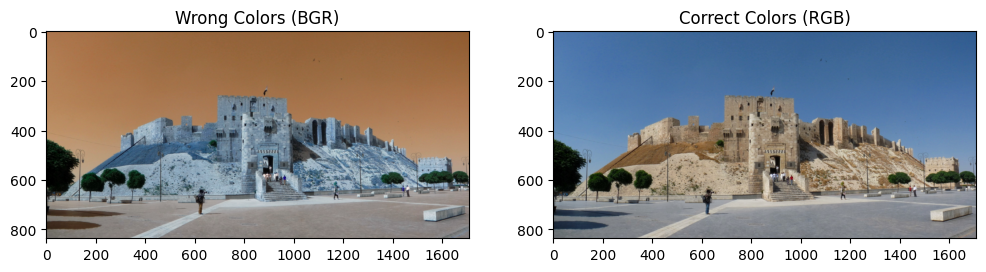

In [ ]:
# التحويل إلى RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Wrong Colors (BGR)')

plt.subplot(1, 2, 2)
plt.imshow(img_rgb)
plt.title('Correct Colors (RGB)')
plt.show()

<div dir="rtl">

### التحدي الثاني: كتابة نص عربي

الآن، بعد أن أصلحنا الألوان، لنحاول وضع عنوان عربي للصورة.

</div>

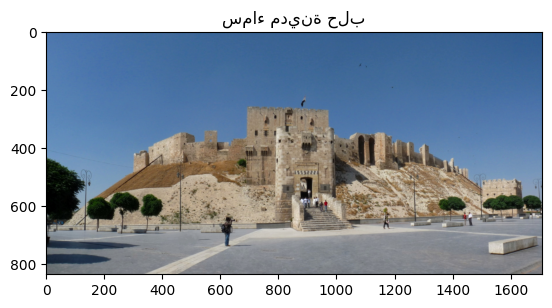

In [ ]:
label ='سماء مدينة حلب'

plt.imshow(img_rgb)
plt.title(label) # الحروف ستكون مقطعة ومعكوسة!
plt.show()

<div dir="rtl">

لماذا تظهر الحروف هكذا؟ لأن المكتبات الافتراضية لا تدعم خصائص اللغة العربية (الاتجاه، تشكيل الحروف). نحتاج لمكتبات وسيطة مثل `arabic_reshaper` لإعادة تشكيل النص.

</div>

Note: you may need to restart the kernel to use updated packages.


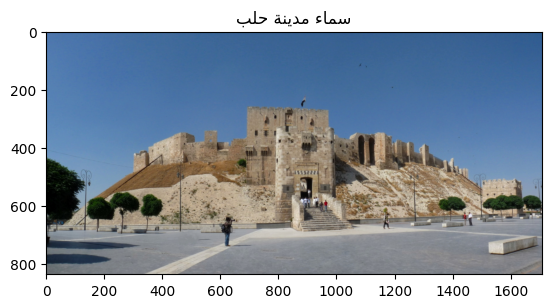

In [ ]:
%pip install arabic_reshaper python-bidi --quiet

import arabic_reshaper
from bidi.algorithm import get_display

def fix_arabic(text):
    reshaped_text = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped_text)
    return bidi_text

plt.imshow(img_rgb)
plt.title(fix_arabic(label)) # النص الآن يظهر بشكل سليم
plt.show()

<div dir="rtl">

---

##  فصل قنوات الألوان (Color Channel Splitting)

 الصورة الملونة التي تراها هي في الحقيقةثلاث صور متدرجة رمادية متراكبة فوق بعضها!

كل بكسل في الصورة الملونة يتكون من ثلاث قيم (B, G, R). عندما "تفصل" القنوات، تحصل على ثلاث صور رمادية، كل واحدة تمثل شدة لون معين في كل نقطة من الصورة.

**تشبيه:** تخيل أن لديك ثلاث أوراق شفافة:
- الورقة الأولى مرسوم عليها كل ما هو أزرق في الصورة
- الورقة الثانية مرسوم عليها كل ما هو أخضر
- الورقة الثالثة مرسوم عليها كل ما هو أحمر

عندما تضعهم فوق بعض ➡️ تحصل على الصورة الملونة الكاملة!


**لماذا هذا مفيد؟**
- معالجة قناة واحدة only (مثلاً القناة الحمراء لتشخيص صور شبكية العين)
- كل قناة تحمل معلومات مختلفة — القناة الزرقاء غالباً فيها تشويش أكثر
- تحليل كل قناة على حدة يعطي فهماً أعمق للصورة

</div>

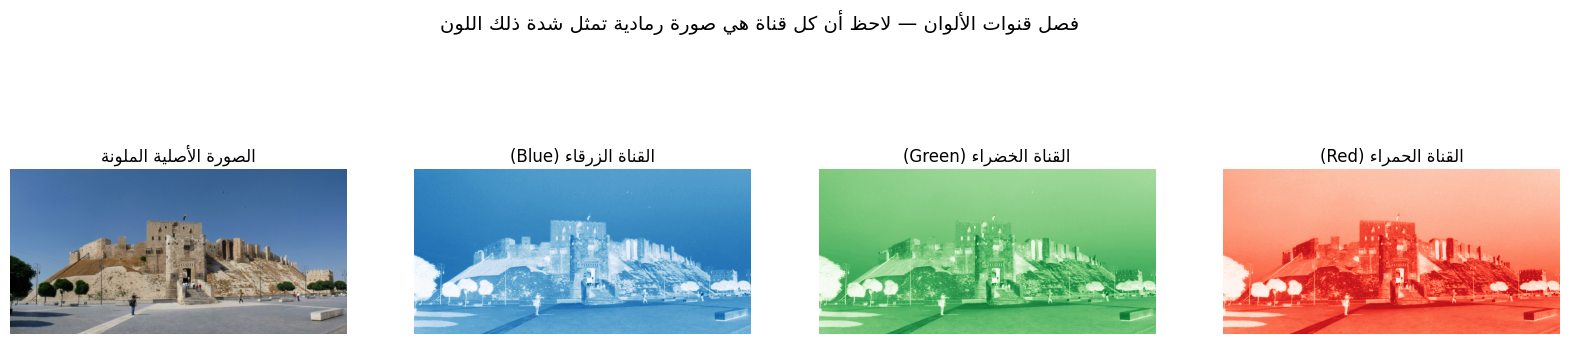

 :ﺔﻴﻠﺻﻷﺍ ﺓﺭﻮﺼﻟﺍ ﺩﺎﻌﺑﺃ(836, 1709, 3)
 :ﻞﺼﻔﻟﺍ ﺪﻌﺑ ﺓﺎﻨﻗ ﻞﻛ ﺩﺎﻌﺑﺃ(836, 1709)!ﺚﻟﺎﺜﻟﺍ ﺪﻌﺒﻟﺍ ﺕﺪﻘﻓ ﺎﻬﻧﺃ ﻆﺣﻻ ←  


In [ ]:
# فصل القنوات الثلاث للصورة
# تذكير: OpenCV تستخدم ترتيب BGR (أزرق، أخضر، أحمر)
B, G, R = cv2.split(img)  # img هي الصورة الأصلية بصيغة BGR

# عرض القنوات المنفصلة — كل قناة هي صورة رمادية!
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title(fix_arabic('الصورة الأصلية الملونة'))
axes[0].axis('off')


axes[1].imshow(B, cmap='Blues')
axes[1].set_title(fix_arabic('القناة الزرقاء (Blue)'))
axes[1].axis('off')

axes[2].imshow(G, cmap='Greens')
axes[2].set_title(fix_arabic('القناة الخضراء (Green)'))
axes[2].axis('off')

axes[3].imshow(R, cmap='Reds')
axes[3].set_title(fix_arabic('القناة الحمراء (Red)'))
axes[3].axis('off')

plt.suptitle(fix_arabic('فصل قنوات الألوان — لاحظ أن كل قناة هي صورة رمادية تمثل شدة ذلك اللون'), fontsize=14)
plt.show()

print(fix_arabic('أبعاد الصورة الأصلية: ') + str(img.shape))
print(fix_arabic('أبعاد كل قناة بعد الفصل: ') + str(B.shape) + fix_arabic('  ← لاحظ أنها فقدت البعد الثالث!'))

<div dir="rtl">

### 💻 تمرين تطبيقي (1): فضاءات الألوان

بفرض أن لديك صورة ملونة باسم `test.jpg` في المجلد الحالي، اكتب كوداً يقوم بالتالي:
1. قراءة الصورة وتخزينها في متغير.
2. تحويل الصورة من نظام `BGR` إلى التدرج الرمادي `Grayscale`.
3. فصل قنوات الصورة الملونة إلى (B, G, R)، ثم اعرض **القناة الخضراء (G)** فقط.

</div>

In [ ]:
# اكتب الكود هنا

<div dir="rtl">

## 2. التحويلات الهندسية (Image Transformations)

معالجة الصور لا تقتصر على الألوان فقط، بل تشمل التحكم في الأبعاد والزوايا. أهم هذه العمليات هي:

### أ. تغيير الحجم (Resizing)
نستخدم `cv2.resize` لتكبير أو تصغير الصورة. 

### ب. القص (Cropping)
بما أن الصورة مصفوفة NumPy، فإن القص يتم ببساطة عبر تقطيع المصفوفة (Slicing).

### ج. التدوير (Rotation)
نستخدم مصفوفة الدوران `cv2.getRotationMatrix2D` ثم نطبقها باستخدام `cv2.warpAffine`.

</div>

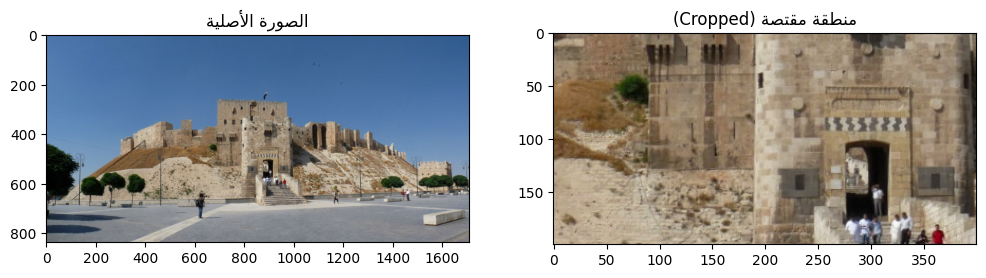

(3 ,1709 ,836) :ﺎﻫﺩﺎﻌﺑﺃ ﺔﻴﻠﺻﻷﺍ ﺓﺭﻮﺼﻟﺍ
(3 ,400 ,200) :ﺎﻫﺩﺎﻌﺑﺃ ﺔﺼﺘﻘﻤﻟﺍ ﺓﺭﻮﺼﻟﺍ


In [ ]:
# ==========================================
# 1. القص (Cropping) — مثال تفاعلي
# ==========================================
# بما أن الصورة هي مصفوفة NumPy، فالقص يتم ببساطة عبر تقطيع المصفوفة (Slicing)
# الصيغة: img[y_start:y_end, x_start:x_end]

img_rgb.shape 

# قص منطقة السماء فقط من الصورة
cropped = img_rgb[400:600, 600:1000]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); plt.imshow(img_rgb); plt.title(fix_arabic('الصورة الأصلية'))
plt.subplot(1, 2, 2); plt.imshow(cropped); plt.title(fix_arabic('منطقة مقتصّة (Cropped)'))
plt.show()

print(fix_arabic('الصورة الأصلية أبعادها: {0}'.format(img_rgb.shape)))
print(fix_arabic('الصورة المقتصّة أبعادها: {0}'.format(cropped.shape)))

<div dir="rtl">

### ب. تغيير الحجم (Resizing)
نستخدم `cv2.resize` لتكبير أو تصغير الصورة. يمكن تحديد الأبعاد الجديدة يدوياً أو بنسبة مئوية.

**لماذا نغير الحجم؟**
- توحيد أبعاد الصور قبل إدخالها لنماذج الذكاء الاصطناعي
- تصغير الصور الكبيرة لتوفير الذاكرة وتسريع المعالجة
- تكبير الصور الصغيرة لرؤية التفاصيل

</div>

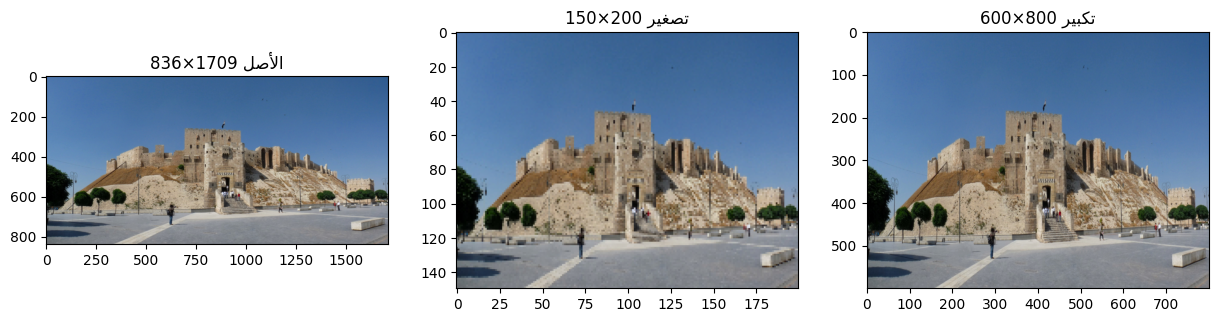

In [ ]:
# مثال ثابت: تغيير الحجم بأبعاد محددة
resized_small = cv2.resize(img_rgb, (200, 150))    # تصغير
resized_large = cv2.resize(img_rgb, (800, 600))     # تكبير

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(img_rgb); plt.title(fix_arabic(f'الأصل {img_rgb.shape[1]}×{img_rgb.shape[0]}'))
plt.subplot(1, 3, 2); plt.imshow(resized_small); plt.title(fix_arabic('تصغير 200×150'))
plt.subplot(1, 3, 3); plt.imshow(resized_large); plt.title(fix_arabic('تكبير 800×600'))
plt.show()

In [ ]:
# @title مثال تفاعلي: تغيير الحجم بنسبة مئوية
def resize_image(scale_percent):
    """تغيير حجم الصورة بنسبة مئوية من الأصل"""
    scale = scale_percent / 100.0
    new_w = int(img_rgb.shape[1] * scale)
    new_h = int(img_rgb.shape[0] * scale)
    resized = cv2.resize(img_rgb, (new_w, new_h))
    
    plt.figure(figsize=(8, 6))
    plt.imshow(resized)
    plt.title(fix_arabic(f'نسبة التكبير: {scale_percent}%  |  الأبعاد: {new_w}×{new_h}'))
    plt.axis('off')
    plt.show()

interact(resize_image, scale_percent=IntSlider(min=10, max=200, step=10, value=100, description=f'{fix_arabic("نسبة التحجيم %")}'))

interactive(children=(IntSlider(value=100, description='% ﻢﻴﺠﺤﺘﻟﺍ ﺔﺒﺴﻧ', max=200, min=10, step=10), Output()),…

<function __main__.resize_image(scale_percent)>

<div dir="rtl">

### ج. التدوير (Rotation)
يتم التدوير بخطوتين:
1. بناء مصفوفة التدوير `cv2.getRotationMatrix2D(المركز, الزاوية, مقياس_التكبير)`
2. تطبيق المصفوفة على الصورة باستخدام `cv2.warpAffine`

**ملاحظة:** الزاوية الموجبة تعني عكس عقارب الساعة.

</div>

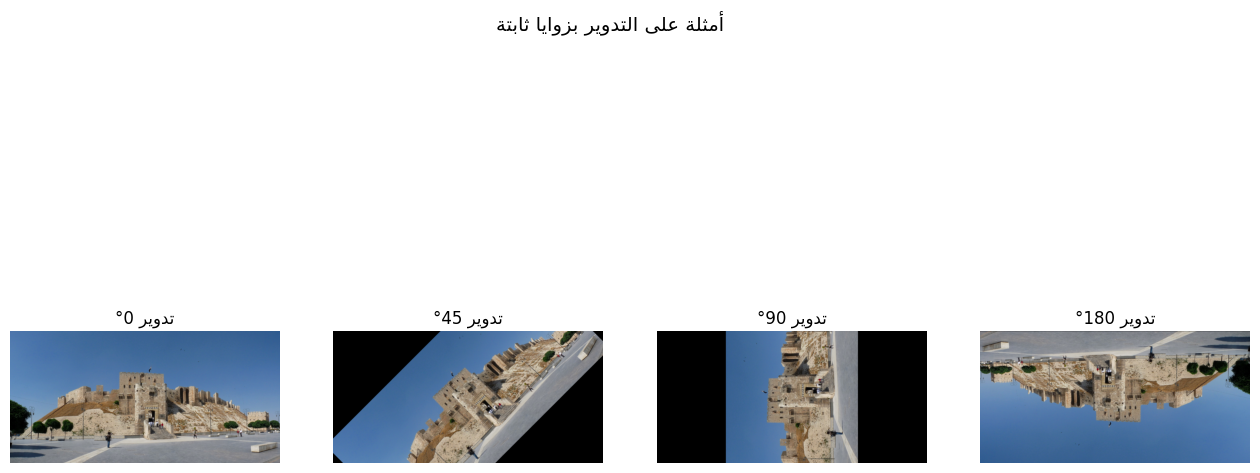

In [ ]:
# مثال ثابت: تدوير بزوايا مختلفة
(h, w) = img_rgb.shape[:2]
center = (w // 2, h // 2)

# تدوير بزوايا متعددة
angles = [0, 45, 90, 180]
rotated_images = []
for angle in angles:
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(img_rgb, M, (w, h))
    rotated_images.append(rotated)

plt.figure(figsize=(16, 8))
for i, (angle, rot_img) in enumerate(zip(angles, rotated_images)):
    plt.subplot(1, 4, i+1)
    plt.imshow(rot_img)
    plt.title(fix_arabic(f'تدوير {angle}°'))
    plt.axis('off')
plt.suptitle(fix_arabic('أمثلة على التدوير بزوايا ثابتة'), fontsize=14)
plt.show()

In [ ]:
# @title مثال تفاعلي: تدوير حر بالدرجات
def rotate_image(angle):
    """تدوير الصورة بزاوية محددة (بالدرجات)"""
    (h, w) = img_rgb.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(img_rgb, M, (w, h))
    
    plt.figure(figsize=(7, 7))
    plt.imshow(rotated)
    plt.title(fix_arabic("الزاوية"))
    plt.axis('off')
    plt.show()

interact(rotate_image, angle=IntSlider(min=0, max=360, step=5, value=0, description=f"الزاوية (°)"))

interactive(children=(IntSlider(value=0, description='الزاوية (°)', max=360, step=5), Output()), _dom_classes=…

<function __main__.rotate_image(angle)>

<div dir="rtl">

### د. الانعكاس (Flipping)
عملية بسيطة لعكس الصورة أفقياً أو عمودياً أو كليهما باستخدام `cv2.flip`.

| الوسيط | المعنى |
|---|---|
| `0` | انعكاس عمودي (حول المحور الأفقي) |
| `1` | انعكاس أفقي (حول المحور العمودي — كالمرآة) |
| `-1` | انعكاس عمودي وأفقي معاً |

</div>

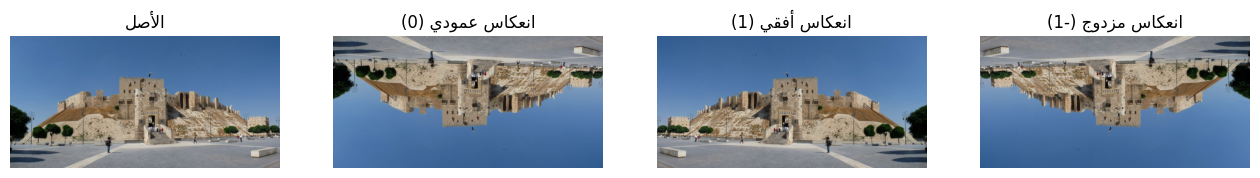

In [ ]:
# أمثلة الانعكاس بأنواعه الثلاثة
flip_vertical   = cv2.flip(img_rgb, 0)   # انعكاس عمودي
flip_horizontal = cv2.flip(img_rgb, 1)   # انعكاس أفقي (مرآة)
flip_both       = cv2.flip(img_rgb, -1)  # انعكاس بالاتجاهين

plt.figure(figsize=(16, 5))
plt.subplot(1, 4, 1); plt.imshow(img_rgb); plt.title(fix_arabic('الأصل')); plt.axis('off')
plt.subplot(1, 4, 2); plt.imshow(flip_vertical); plt.title(fix_arabic('انعكاس عمودي (0)')); plt.axis('off')
plt.subplot(1, 4, 3); plt.imshow(flip_horizontal); plt.title(fix_arabic('انعكاس أفقي (1)')); plt.axis('off')
plt.subplot(1, 4, 4); plt.imshow(flip_both); plt.title(fix_arabic('انعكاس مزدوج (-1)')); plt.axis('off')
plt.show()

<div dir="rtl">

### 💻 تمرين تطبيقي (2): التحويلات الهندسية

لديك صورة بأبعاد كبيرة جداً ونريد تجهيزها لإدخالها في نموذج ذكاء اصطناعي. اكتب كوداً يقوم بالتالي:
1. تغيير أبعاد الصورة (Resize) لتصبح $300 \times 300$ بكسل.
2. تدوير الصورة بزاوية 90 درجة باتجاه عقارب الساعة.
3. قص (Crop) منتصف الصورة تماماً ليصبح بأبعاد $100 \times 100$.

</div>

In [ ]:
# اكتب الكود هنا

<div dir="rtl">

## 3. الرسم والتعليق على الصور (Drawing & Annotation)

الرسم على الصور مهارة أساسية لتوضيح النتائج (مثل تحديد موقع وجه أو كتابة نص يصف كائناً في الصورة). في مكتبة OpenCV، تقوم دوال الرسم بتعديل الصورة مباشرة (In-place)، لذلك من الأفضل دائماً أخذ **نسخة (Copy)** من الصورة الأصلية قبل الرسم عليها لتجنب تخريبها.

إليك شرح لأهم دوال الرسم وشكل التعليمة (Syntax) الخاصة بها:

### 1. رسم خط (Line)
* **شكل التعليمة:**
  `cv2.line(img, pt1, pt2, color, thickness)`
* **شرح المدخلات:**
  * `img`: الصورة التي سنرسم عليها.
  * `pt1`: إحداثيات نقطة البداية للخط `(x1, y1)`.
  * `pt2`: إحداثيات نقطة النهاية للخط `(x2, y2)`.
  * `color`: لون الخط بنظام `(R, G, B)`.
  * `thickness`: سماكة الخط بالبكسل.

### 2. رسم مستطيل (Rectangle)
* **شكل التعليمة:**
  `cv2.rectangle(img, pt1, pt2, color, thickness)`
* **شرح المدخلات:**
  * `img`: الصورة.
  * `pt1`: إحداثيات الزاوية العلوية اليسرى للمستطيل `(x1, y1)`.
  * `pt2`: إحداثيات الزاوية السفلية اليمنى للمستطيل `(x2, y2)`.
  * `color`: اللون `(R, G, B)`.
  * `thickness`: السماكة. **(ملاحظة: إذا وضعت القيمة `-1` سيتم تلوين المستطيل بالكامل من الداخل)**.

### 3. رسم دائرة (Circle)
* **شكل التعليمة:**
  `cv2.circle(img, center, radius, color, thickness)`
* **شرح المدخلات:**
  * `img`: الصورة.
  * `center`: إحداثيات مركز الدائرة `(x, y)`.
  * `radius`: طول نصف القطر بالبكسل.
  * `color`: اللون `(R, G, B)`.
  * `thickness`: السماكة (أيضاً القيمة `-1` ترسم دائرة ممتلئة).

### 4. كتابة نص (Text)
* **شكل التعليمة:**
  `cv2.putText(img, text, org, fontFace, fontScale, color, thickness, lineType)`
* **شرح المدخلات:**
  * `img`: الصورة.
  * `text`: النص المراد كتابته (يجب أن يكون باللغة الإنجليزية، OpenCV لا تدعم العربية مباشرة).
  * `org`: الإحداثيات المرجعية للنص (الزاوية السفلية اليسرى لأول حرف) `(x, y)`.
  * `fontFace`: نوع الخط (مثل `cv2.FONT_HERSHEY_SIMPLEX`).
  * `fontScale`: حجم الخط (مقياس التكبير).
  * `color`: اللون `(R, G, B)`.
  * `thickness`: سماكة حروف النص.
  * `lineType`: نوع حواف الخط (يُفضل استخدام `cv2.LINE_AA` لجعل حواف النص ناعمة وواضحة).

</div>

In [ ]:


# تحميل الصورة (بافتراض وجود دالة load_image أو يمكنك استخدام cv2.imread)
canvas = load_image('sky.jpg')

# تحويل الألوان ليتم عرضها بشكل صحيح في Matplotlib
canvas = cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB)

# نأخذ نسخة من الصورة كي نرسم عليها ولا نخرب الصورة الأصلية
draw_img = canvas.copy() 

# ==========================================
# 1. رسم خط (Line)
# ==========================================
# (0,0): نقطة البداية في الزاوية العلوية اليسرى
# (draw_img.shape[1], draw_img.shape[0]): نقطة النهاية في الزاوية السفلية اليمنى
# (255, 255, 255): لون أبيض نقي
# 2: سماكة الخط 2 بكسل
cv2.line(draw_img, (0, 0), (draw_img.shape[1], draw_img.shape[0]), (255, 255, 255), 2)  

# ==========================================
# 2. رسم مستطيل (Rectangle)
# ==========================================
# (800, 700): الزاوية العلوية اليسرى للمستطيل
# (1000, 350): الزاوية السفلية اليمنى للمستطيل
# (0, 255, 0): اللون الأخضر (لأننا نعمل بنظام RGB الآن)
# 5: سماكة إطار المستطيل 5 بكسل
cv2.rectangle(draw_img, (800, 700), (1000, 350), (0, 255, 0), 5)  

# ==========================================
# 3. رسم دائرة (Circle)
# ==========================================
# (300, 225): إحداثيات مركز الدائرة (x=300, y=225)
# 50: طول نصف القطر 50 بكسل
# (255, 0, 0): اللون الأحمر
# -1: هذه القيمة تعني أن الدائرة ستكون ممتلئة (Filled) بالكامل من الداخل بدلاً من رسم إطار فقط
cv2.circle(draw_img, (300, 225), 50, (255, 0, 0), -1) 

# ==========================================
# 4. كتابة نص (Text)
# ==========================================
# "front door": النص الذي سيتم طباعته
# (820, 320): إحداثيات بداية النص
# cv2.FONT_HERSHEY_SIMPLEX: نوع الخط المستخدم
# 1: حجم الخط (مقياس التكبير)
# (255, 255, 0): اللون الأصفر (مزيج بين الأحمر والأخضر)
# 3: سماكة خط الحروف
# cv2.LINE_AA: تقنية (Anti-Aliasing) لتنعيم حواف النص وجعله يبدو أجمل
cv2.putText(draw_img, "front door", (820, 320), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 3, cv2.LINE_AA)

# ==========================================
# 5. عرض النتيجة النهائية
# ==========================================
plt.figure(figsize=(10, 6))
plt.imshow(draw_img)
plt.title(fix_arabic('الرسم على الصور: خط، مستطيل، دائرة، ونص')) # بافتراض وجود دالة fix_arabic
plt.axis('off') # إخفاء المحاور لرؤية الصورة بشكل أوضح
plt.show()

<div dir="rtl">

## 4. الهيستوغرام: كيف يحلل الحاسوب الإضاءة؟

الهيستوغرام هو أداة إحصائية تحول المصفوفة ثنائية الأبعاد (الصورة) إلى توزيع إحصائي أحادي البعد. 

**كيف يتم بناؤه؟**
تخيل أن الحاسوب يمر بماسح ضوئي على كل بكسل في الصورة. في كل مرة يجد فيها بكسل بقيمة معينة، يقوم بإضافة علامة في العمود المقابل لتلك القيمة في الرسم البياني. 

انظر لهذا العرض المتحرك الذي يشرح العملية بدقة:

<img src="https://raw.githubusercontent.com/mohammedmka95/Medad-CV-Bootcamp/main/Week2/images/histogram_explanation.gif" width="500">

### مثال واقعي: الفرق بين النهار والليل
يختلف شكل منحنى الهيستوغرام بشكل كبير حسب إضاءة المشهد. في الصور الليلية، تتركز البيانات في اليسار (قيم منخفضة)، بينما في الصور النهارية، تتوزع البيانات نحو اليمين.

</div>

In [ ]:
def plot_hist_side_by_side(filename, title):
    img = load_image(filename)
    img = cv2.resize(img, (600, 400))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
    
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.axis('off'); plt.title(fix_arabic(title))
    plt.subplot(1, 2, 2); plt.plot(hist, color='black'); plt.fill_between(range(256), hist.flatten(), color='gray', alpha=0.3); plt.title(fix_arabic('الهيستوغرام'))
    plt.show()

plot_hist_side_by_side('day_time.jpg', 'صورة نهارية')
plot_hist_side_by_side('Night_time.png', 'صورة ليلية')

<div dir="rtl">

## 5. مطابقة الهيستوغرام (Histogram Matching)

**ما هي الفائدة؟**
أحياناً نريد توحيد مظهر عدة صور ملتقطة في ظروف إضاءة مختلفة. مطابقة الهيستوغرام هي عملية تعديل بكسلات صورة (Source) لتأخذ نفس التوزيع الإحصائي لصورة أخرى (Reference).

**التطبيقات:**
- توحيد صور الأقمار الصناعية الملتقطة في أوقات مختلفة.
- توحيد الصور الطبية لتسهيل التشخيص الآلي (مثل توحيد إضاءة وألوان صور شبكية العين المأخوذة بكاميرات مختلفة).

### كيف نقوم بذلك برمجياً؟
لأن مكتبة `OpenCV` لا تحتوي على دالة مباشرة وبسيطة لمطابقة الهيستوغرام، نلجأ عادةً في بايثون إلى مكتبة معالجة الصور الشهيرة `scikit-image`، والتي توفر دالة جاهزة وممتازة لهذا الغرض وهي `match_histograms`.

* **شكل التعليمة:**
  `matched_image = exposure.match_histograms(image, reference, channel_axis=-1)`

* **شرح المدخلات:**
  * `image`: الصورة الأصلية (Source) التي نريد تعديل إضاءتها وألوانها.
  * `reference`: الصورة المرجعية (Reference) التي نريد أن نقلّد توزيع الإضاءة فيها.
  * `channel_axis`: نمرر القيمة `-1` لنخبر الدالة أن الصورة ملونة ولها قنوات (RGB) ويجب مطابقة كل قناة لونية على حدة.

</div>

<div dir="rtl">

<img src="https://raw.githubusercontent.com/mohammedmka95/Medad-CV-Bootcamp/main/Week2/images/fundus%20images.jpg" width="350">

</div>

<div dir="rtl">
الصور في السطر الثاني نرى ان الهيستوغرام تم  مطابقته مع الصورة الاولى العليا اليسرى

</div>


<div dir="rtl">
الصور ذات الهيستوغرام المطابق اسهل في المعالجة فيما بعد  مثال اختيار العتبات  .. الخ
</div>


In [ ]:
import cv2
import matplotlib.pyplot as plt

# استدعاء أداة مطابقة الهيستوغرام من مكتبة scikit-image
from skimage import exposure

# ==========================================
# 1. قراءة الصور (الصورة الأصلية والمرجعية لمدينة حلب)
# ==========================================
# الصورة الأصلية (التي نريد تعديل ألوانها وإضاءتها)
src_img = load_image('aleppo_source.jpg') 
src_img = cv2.cvtColor(src_img, cv2.COLOR_BGR2RGB)

# الصورة المرجعية (التي تحمل الإضاءة والألوان المطلوبة)
ref_img = load_image('aleppo_ref.jpg') 
ref_img = cv2.cvtColor(ref_img, cv2.COLOR_BGR2RGB)

# ==========================================
# 2. تطبيق مطابقة الهيستوغرام
# ==========================================
# نمرر الصورة المراد تعديلها، ثم الصورة المرجعية
# نستخدم channel_axis=-1 لأن صورنا ملونة (3 قنوات)
matched_img = exposure.match_histograms(src_img, ref_img, channel_axis=-1)

# ==========================================
# 3. عرض النتائج للمقارنة
# ==========================================
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

# عرض الصورة الأصلية (قبل التعديل)
axes[0].imshow(src_img)
axes[0].set_title("1. Source (Aleppo)")
axes[0].axis('off')

# عرض الصورة المرجعية (التي قلدناها)
axes[1].imshow(ref_img)
axes[1].set_title("2. Reference (Aleppo)")
axes[1].axis('off')

# عرض النتيجة النهائية
axes[2].imshow(matched_img)
axes[2].set_title("3. Matched Result")
axes[2].axis('off')

plt.tight_layout()
plt.show()

<div dir="rtl">

## 8. العتبة (Thresholding)

العتبة هي العملية التي تحول الصورة إلى أسود وأبيض فقط. 

**أمثلة الاستخدام:**
1. **التعرف الضوئي على الحروف (OCR):** تحويل النص المكتوب إلى أسود وأبيض ليسهل على الحاسوب قراءته.
2. **عزل الأجسام:** فصل جسم محدد عن الخلفية لقياس أبعاده أو عده.

</div>

In [ ]:
# 1. قراءة الصورة وتحويلها لرمادي
gray = cv2.cvtColor(load_image("Book2.jpeg"), cv2.COLOR_BGR2GRAY)

# 2. إنشاء عنصر مخصص لعرض الصورة من ipywidgets (بديل للـ HTML box)
image_widget = widgets.Image(
    format='png', 
    width=400, 
    height=400
)

# 3. دالة التحديث التي تعدل بايتات الصورة مباشرة
def update_thresh(val):
    # تطبيق التعتيم باستخدام OpenCV
    _, th = cv2.threshold(gray, val, 255, cv2.THRESH_BINARY)
    
    # تحويل مصفوفة الصورة (Numpy Array) إلى صيغة PNG ثم إلى Bytes ليقبلها الويدجت
    _, encoded_img = cv2.imencode('.png', th)
    image_widget.value = encoded_img.tobytes()

# 4. التفاعل باستخدام widgets.interactive تماماً مثل مثالك الناجح
interactive_plot = widgets.interactive(
    update_thresh, 
    val=widgets.IntSlider(min=0, max=255, value=127, description='Threshold')
)

# 5. عرض عنصر التحكم وصندوق الصورة معاً
display(interactive_plot, image_widget)

In [ ]:
# 1. قراءة الصورة الأصلية (بصيغة BGR الافتراضية في OpenCV)
img_bgr = load_image("Book2.jpeg")

# 2. عمليات التحويل والمعالجة
# أ - تحويل الصورة الأصلية إلى RGB للعرض الصحيح في matplotlib
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# ب - تحويل الصورة إلى التدرج الرمادي
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

threshold_value = 125

# ج - تطبيق التعتيم الثنائي بقيمة ثابتة 
_, binary = cv2.threshold(gray, threshold_value, 255, cv2.THRESH_BINARY)

# 3. إنشاء نافذة عرض تحتوي على صف واحد و 3 أعمدة
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# العمود الأول: الصورة الأصلية (ملونة)
axes[0].imshow(img_rgb)
axes[0].set_title(fix_arabic("الصورة الأصلية (ملونة)"))
axes[0].axis("off") # إخفاء المحاور

# العمود الثاني: صورة التدرج الرمادي
axes[1].imshow(gray, cmap="gray")
axes[1].set_title(fix_arabic("الصورة بالتدرج الرمادي (Grayscale)"))
axes[1].axis("off")

# العمود الثالث: الصورة الثنائية (النتيجة)
axes[2].imshow(binary, cmap="gray")
axes[2].set_title(fix_arabic("الصورة الثنائية (Binary)"))
axes[2].axis("off")

# ضبط المسافات لمنع التداخل
plt.tight_layout()
plt.show()

<div dir="rtl">


### 💻 تمرين تطبيقي (3): العمليات الثنائية (Thresholding)

لديك صورة لورقة ممسوحة ضوئياً (Scanned Document)، ونريد تحويلها إلى (أسود وأبيض نقي) للتخلص من الظلال وخلفية الورقة:
1. حوّل الصورة إلى التدرج الرمادي.
2. طبّق عليها عتبة ثنائية `cv2.threshold` بحيث: أي بكسل قيمته الإضاءتية أعلى من `130` يتحول إلى أبيض (`255`)، وما دونه يتحول إلى أسود (`0`).

***

</div>


In [ ]:
# اكتب الكود هنا

<div dir="rtl">

### كيف نختار قيمة العتبة المناسبة؟

اختيار قيمة العتبة ليس عشوائياً! هناك عدة طرق:

| الطريقة | الوصف | متى نستخدمها؟ |
|---|---|---|
| **يدوية (Static)** | نختار قيمة ثابتة مثل 127 | عندما تكون الإضاءة ثابتة ومعروفة |
| **طريقة أوتسو (Otsu)** | الخوارزمية تختار أفضل قيمة تلقائياً | عندما يكون هناك قمتان في الهيستوغرام (جسم + خلفية) |
| **العتبة التكيّفية (Adaptive)** | قيمة عتبة مختلفة لكل منطقة من الصورة | عندما تكون الإضاءة غير متساوية في الصورة |

**المبدأ الأساسي:** ننظر إلى الهيستوغرام!
- إذا كان فيه قمتان واضحتان ➡️ قيمة العتبة تكون في الوادي بينهما
- إذا كان فيه قمة واحدة ➡️ العتبة التكيّفية قد تكون أفضل

</div>

In [ ]:
# ==========================================
# طريقة أوتسو (Otsu's Method) — تختار العتبة تلقائياً!
# ==========================================
# أوتسو تجرب كل قيم العتبة الممكنة وتختار القيمة التي تعطي أفضل فصل
# بين الجسم والخلفية (أقل تباين داخل كل مجموعة)
gray_book = cv2.cvtColor(load_image("Book2.jpeg"), cv2.COLOR_BGR2GRAY)

# عتبة يدوية للمقارنة
_, manual_thresh = cv2.threshold(gray_book, 127, 255, cv2.THRESH_BINARY)

# طريقة أوتسو — لاحظ أننا نمرر 0 كقيمة ابتدائية ثم نضيف cv2.THRESH_OTSU
otsu_val, otsu_thresh = cv2.threshold(gray_book, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(gray_book, cmap='gray'); axes[0].set_title(fix_arabic('الصورة الرمادية الأصلية')); axes[0].axis('off')
axes[1].imshow(manual_thresh, cmap='gray'); axes[1].set_title(fix_arabic('عتبة يدوية: 127')); axes[1].axis('off')
axes[2].imshow(otsu_thresh, cmap='gray'); axes[2].set_title(fix_arabic(f'عتبة أوتسو التلقائية: {otsu_val:.0f}')); axes[2].axis('off')
plt.suptitle(fix_arabic('يدوي vs أوتسو — لاحظ أن أوتسو اختار قيمة أفضل تلقائياً!'), fontsize=14)
plt.show()

print(fix_arabic(f'قيمة العتبة التي اختارتها أوتسو: {otsu_val:.0f}'))

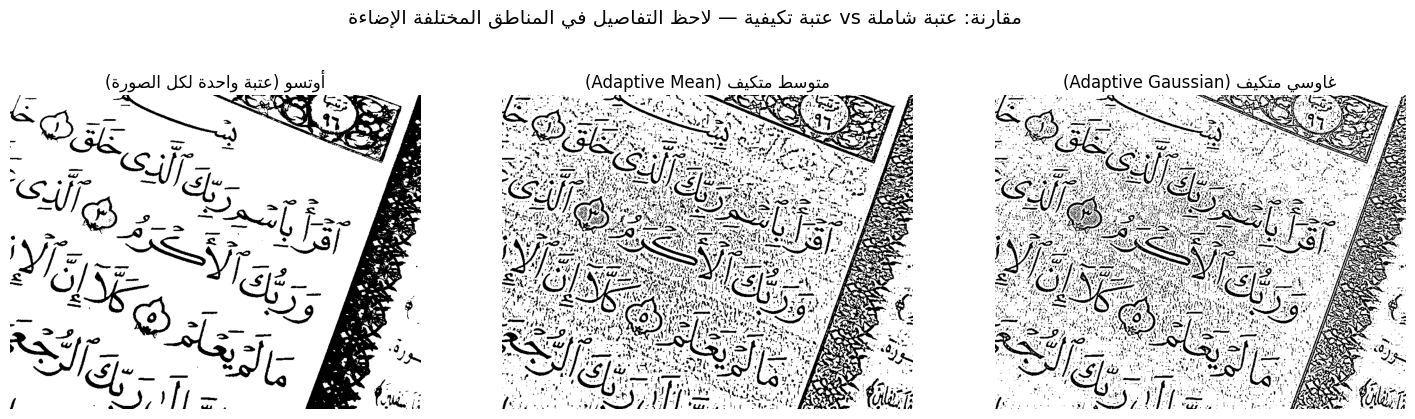

In [ ]:
# ==========================================
# العتبة التكيّفية (Adaptive Thresholding)
# ==========================================
# عندما تكون الإضاءة غير متساوية في أجزاء الصورة، العتبة الواحدة لكل الصورة تفشل.
# الحل: العتبة التكيّفية — تحسب قيمة عتبة مختلفة لكل بكسل بناءً على جيرانه!

# طريقتان لحساب العتبة المحلية:
adaptive_mean = cv2.adaptiveThreshold(gray_book, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)
adaptive_gauss = cv2.adaptiveThreshold(gray_book, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(otsu_thresh, cmap='gray'); axes[0].set_title(fix_arabic('أوتسو (عتبة واحدة لكل الصورة)')); axes[0].axis('off')
axes[1].imshow(adaptive_mean, cmap='gray'); axes[1].set_title(fix_arabic('متوسط متكيّف (Adaptive Mean)')); axes[1].axis('off')
axes[2].imshow(adaptive_gauss, cmap='gray'); axes[2].set_title(fix_arabic('غاوسي متكيّف (Adaptive Gaussian)')); axes[2].axis('off')
plt.suptitle(fix_arabic('مقارنة: عتبة شاملة vs عتبة تكيّفية — لاحظ التفاصيل في المناطق المختلفة الإضاءة'), fontsize=14)
plt.show()

<div dir="rtl">

---

## 8. العمليات على الصور الثنائية (Binary Image Operations)

بعد أن نحول الصورة إلى أسود وأبيض (ثنائية)، تفتح أمامنا مجموعة قوية من العمليات لتحليل وتنظيف وقياس محتوى الصورة. هذه العمليات هي أساس كل تطبيقات الرؤية الحاسوبية تقريباً.

**تحضير الصورة الأساسية:** سنستخدم الصورة التالية كأساس لكل الأمثلة القادمة.

</div>

In [ ]:
# تحضير الصورة الأساسية لجميع أمثلة العمليات الثنائية
binary_base = load_image("Book2.jpeg")
binary_base = cv2.cvtColor(binary_base, cv2.COLOR_BGR2GRAY)
_, binary_base = cv2.threshold(binary_base, 127, 255, cv2.THRESH_BINARY)

# للتذكير: الأبيض = 255 (الجسم/المقدمة)، الأسود = 0 (الخلفية)
plt.figure(figsize=(6, 6))
plt.imshow(binary_base, cmap='gray')
plt.title(fix_arabic('الصورة الثنائية الأساسية — الأبيض = المقدمة، الأسود = الخلفية'))
plt.axis('off')
plt.show()

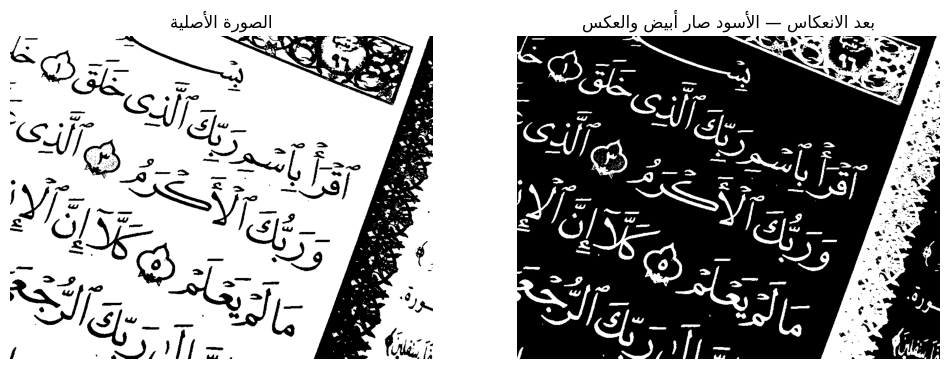

In [ ]:
# 1. الانعكاس (Inversion) — تبديل الأبيض بالأسود والعكس
# الاستخدام: عندما يكون الجسم أغمق من الخلفية ونريد جعله أبيض
inverted = cv2.bitwise_not(binary_base)  # العملية الأساسية — سطر واحد!

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(binary_base, cmap='gray'); axes[0].set_title(fix_arabic('الصورة الأصلية')); axes[0].axis('off')
axes[1].imshow(inverted, cmap='gray'); axes[1].set_title(fix_arabic('بعد الانعكاس — الأسود صار أبيض والعكس')); axes[1].axis('off')
plt.show()

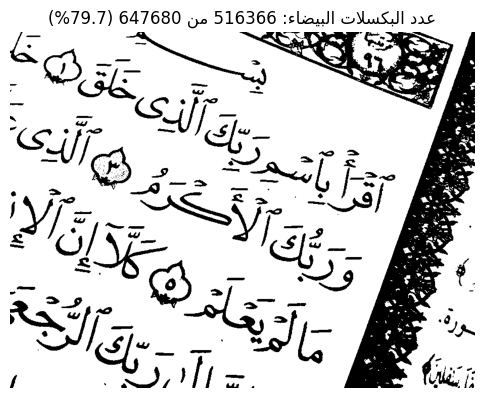

In [ ]:
# 2. حساب المساحة (Area) — عدّ البكسلات البيضاء = حجم الجسم
# الاستخدام: قياس حجم خلايا، أورام، أو قطع في التصنيع
white_pixels = cv2.countNonZero(binary_base)  # العملية الأساسية — سطر واحد!
total_pixels = binary_base.shape[0] * binary_base.shape[1]
pct = 100 * white_pixels / total_pixels

# عرض النتيجة على الصورة
plt.figure(figsize=(6, 6))
plt.imshow(binary_base, cmap='gray')
plt.title(fix_arabic(f'عدد البكسلات البيضاء: {white_pixels} من {total_pixels} ({pct:.1f}%)'))
plt.axis('off')
plt.show()

In [ ]:
# 3. التراكب (Overlay) — عرض النتيجة الثنائية بالألوان على الصورة الأصلية
# الاستخدام: للعروض التقديمية، التصحيح (debugging)، وتوضيح النتائج
original_book = cv2.cvtColor(load_image("Book2.jpeg"), cv2.COLOR_BGR2RGB)
overlay = original_book.copy()
overlay[binary_base == 255] = [255, 0, 0]  # تلوين المناطق البيضاء بالأحمر — سطر واحد!

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(original_book); axes[0].set_title(fix_arabic('الصورة الأصلية')); axes[0].axis('off')
axes[1].imshow(overlay); axes[1].set_title(fix_arabic('التراكب — المناطق البيضاء مظللة بالأحمر')); axes[1].axis('off')
plt.show()

<div dir="rtl">

## 9. معالجة الفيديو (Video Processing)

**ما هو الفيديو برمجياً؟**
الفيديو ليس ملفاً غامضاً، بل هو ببساطة **سلسلة متتالية من الصور الثابتة** (Frames) تُعرض بسرعة (مثلاً 30 إطاراً في الثانية). 

**مبدأ المعالجة:**
بما أن الفيديو هو صور متتابعة، فإن كل ما تعلمناه اليوم (تغيير حجم، تحويل ألوان، عتبة، عمليات ثنائية) يمكن تطبيقه على الفيديو عبر معالجة كل إطار على حدة داخل حلقة تكرارية (Loop).

**خطوات المعالجة المعتادة:**
1. فتح مصدر الفيديو (كاميرا أو ملف).
2. قراءة الإطار الحالي.
3. تطبيق خوارزميات المعالجة (مثلاً تحويل لرمادي).
4. عرض النتيجة أو حفظها.
5. تكرار العملية حتى نهاية الفيديو.

---

### الملفات المساعدة المرفقة

لفتح الكاميرا مباشرة وعرض النتائج بشكل تفاعلي (وهو أمر يصعب عمله داخل Jupyter Notebook)، تم تزويدكم بملف بايثون جاهزة للتشغيل المباشر:


#### 2. `simple_threshold.py` — عتبة ثنائية مباشرة وبسيطة
 يفتح الكاميرا، يحول كل إطار إلى تدرج رمادي، ثم يطبق عتبة ثابتة (قيمة 127). مناسب لفهم الهيكل الأساسي لحلقة الفيديو بدون تعقيدات إضافية.


**للتشغيل:** افتح terminal واكتب:
```bash

python simple_threshold.py

</div>

In [ ]:
# الهيكل البرمجي الأساسي لمعالجة الفيديو
cap = cv2.VideoCapture(0) # 0 تعني الكاميرا الافتراضية

while cap.isOpened():
    ret, frame = cap.read() # قراءة إطار واحد
    if not ret: break
    
    # مثال: تحويل كل إطار في الفيديو إلى تدرج رمادي
    # gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
    # عرض الإطار (هذا السطر يعمل في بيئة محلية وليس في Colab بسهولة)
    # cv2.imshow('Video', frame)
    
    break # توقفنا هنا لأننا في المفكرة

cap.release()
cv2.destroyAllWindows()

<div dir="rtl">

### 💻 التطبيق النهائي:  تحليل الإضاءة المباشر 

الآن دعونا ندمج عدة مفاهيم معاً! اكتب كوداً يقوم بتشغيل الكاميرا وتحليل مستوى إضاءة المشهد في الوقت الفعلي:
1. التقط بث الكاميرا الافتراضية.
2. داخل حلقة `while`، اقرأ الإطارات وحوّل كل إطار فوراً إلى التدرج الرمادي (Grayscale).
3. احسب **متوسط قيمة البكسلات (Average Pixel Value)** للإطار الرمادي لمعرفة مستوى الإضاءة العام (يمكنك استخدام `numpy.mean`).
4. استخدم دالة الرسم `cv2.putText` لطباعة قيمة هذا المتوسط كنص متحرك مباشرة فوق الفيديو أثناء عرضه.
5. اعرض الفيديو، وأغلق النافذة والكاميرا بأمان عند الضغط على مفتاح `"q"`.

***
</div>

In [ ]:
#اكتب الكود هنا

<div dir="rtl">

---
## مراجع إضافية
- وثائق OpenCV الرسمية: [docs.opencv.org](https://docs.opencv.org/)
- مصدر صورة السماء: [المعرفة - marefa.org](https://www.marefa.org)
- الرسوم التوضيحية: Pinecone.io

</div>